# Diagnostics · regB threshold vs production combined-emb

**Primary interface** for inspecting whether the "max-precision at recall≥0.5"
threshold sits at the right knee. Calls `channel_heads.*` only:

- `channel_heads.eval` — `outlet_group_holdout`, `classification_metrics`,
  `f1_optimal_threshold`
- `channel_heads.inference` — `load_feature_columns`, `load_threshold`,
  `load_xgb_model`

It is **read-only**: it renders the PR curves + Mars probability histograms
inline and writes no PNGs.

> Uses the regB and production combined-emb model artifacts under `models/`. If
> any are absent, the affected config is skipped.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import precision_recall_curve

from channel_heads.config import PROJECT_ROOT
from channel_heads.eval import (
    classification_metrics,
    f1_optimal_threshold,
    outlet_group_holdout,
)
from channel_heads.inference import load_feature_columns, load_threshold, load_xgb_model

RESULTS = PROJECT_ROOT / "data/results"
MODELS = PROJECT_ROOT / "models"

CONFIGS = {
    "regB": dict(
        csv=RESULTS / "master_dataset_regB_with_emb.csv",
        model=MODELS / "xgb_geom_plus_cnn_emb_regB.json",
        feats=MODELS / "feature_columns_geom_plus_cnn_emb_regB.txt",
        thr=MODELS / "optimal_threshold_geom_plus_cnn_emb_regB.txt",
        color="#1f6fb4",
    ),
    "production_emb": dict(
        csv=RESULTS / "master_dataset_v4_cnn_full.csv",
        model=MODELS / "xgb_geom_plus_cnn_emb.json",
        feats=MODELS / "feature_columns_geom_plus_cnn_emb.txt",
        thr=MODELS / "optimal_threshold_geom_plus_cnn_emb.txt",
        color="#b5533f",
    ),
}
available = {k: v for k, v in CONFIGS.items()
             if all(v[p].exists() for p in ("csv", "model", "feats", "thr"))}
print("available configs:", list(available))

available configs: ['regB', 'production_emb']


## Score the held-out Earth test set — via the package

In [2]:
def score_test(cfg):
    feats = load_feature_columns(cfg["feats"])
    df = pd.read_csv(cfg["csv"])
    _, test_idx = outlet_group_holdout(df)
    y = df["y"].astype(int).to_numpy()[test_idx]
    X_test = df[feats].to_numpy(dtype=float)[test_idx]
    proba = load_xgb_model(cfg["model"]).predict_proba(X_test)[:, 1]
    threshold = load_threshold(cfg["thr"])
    return y, proba, threshold


results = {}
for name, cfg in available.items():
    y, proba, thr = score_test(cfg)
    m = classification_metrics(y, proba, thr)
    f1_thr, f1_max = f1_optimal_threshold(y, proba)
    prec, rec, prc_thr = precision_recall_curve(y, proba)
    results[name] = dict(y=y, proba=proba, thr=thr, m=m, f1_thr=f1_thr,
                         f1_max=f1_max, prec=prec, rec=rec, prc_thr=prc_thr,
                         color=cfg["color"])
    print(f"[{name}] n={len(y)} pos={y.mean():.3f}  ROC={m['roc_auc']:.3f} "
          f"PR={m['pr_auc']:.3f}  thr={thr:.3f} -> P={m['precision']:.3f} "
          f"R={m['recall']:.3f} F1={m['f1']:.3f}  |  F1-opt thr={f1_thr:.3f} (F1={f1_max:.3f})")

[regB] n=1609 pos=0.317  ROC=0.876 PR=0.764  thr=0.761 -> P=0.780 R=0.508 F1=0.615  |  F1-opt thr=0.548 (F1=0.712)
[production_emb] n=709 pos=0.412  ROC=0.918 PR=0.880  thr=0.857 -> P=0.914 R=0.510 F1=0.655  |  F1-opt thr=0.439 (F1=0.825)


## Earth test PR curves (inline)

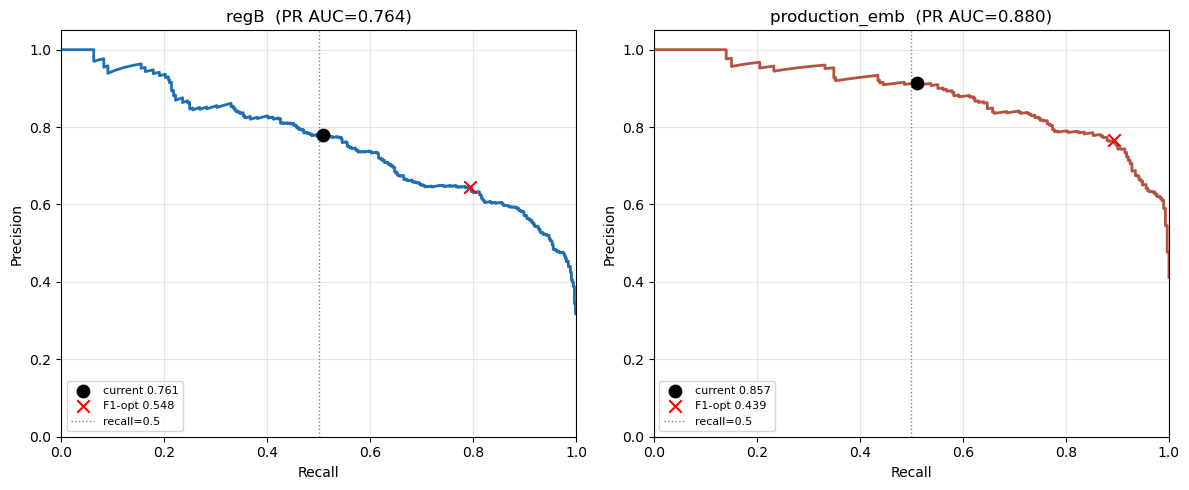

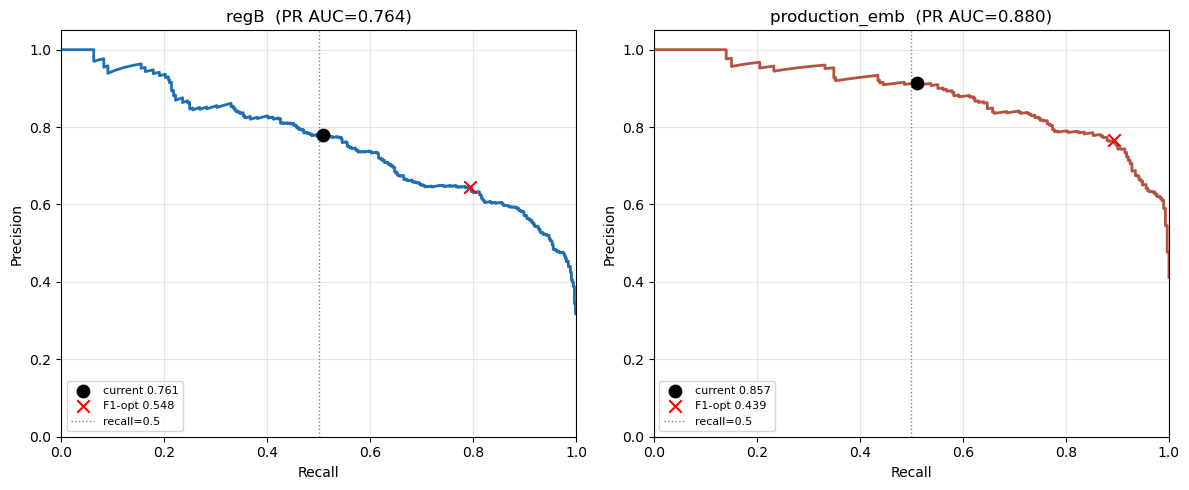

In [3]:
n = len(results)
fig, axes = plt.subplots(1, max(n, 1), figsize=(6 * max(n, 1), 5), squeeze=False)
for ax, (name, r) in zip(axes[0], results.items()):
    ax.plot(r["rec"], r["prec"], color=r["color"], lw=2)
    for thr_val, marker, col, lab in [
        (r["thr"], "o", "black", f"current {r['thr']:.3f}"),
        (r["f1_thr"], "x", "red", f"F1-opt {r['f1_thr']:.3f}"),
    ]:
        mask = r["prc_thr"] >= thr_val
        if mask.any():
            i = int(np.argmax(mask))
            ax.scatter(r["rec"][i], r["prec"][i], s=80, marker=marker, c=col, zorder=5, label=lab)
    ax.axvline(0.5, color="gray", ls=":", lw=1, label="recall=0.5")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.05)
    ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
    ax.set_title(f"{name}  (PR AUC={r['m']['pr_auc']:.3f})")
    ax.grid(alpha=0.3); ax.legend(loc="lower left", fontsize=8)
fig.tight_layout()
fig

## Mars probability distributions (inline)

regB            median=0.829  frac>=0.5=81.4%  frac>=0.9=27.8%
production_emb  median=0.944  frac>=0.5=82.2%  frac>=0.9=59.0%


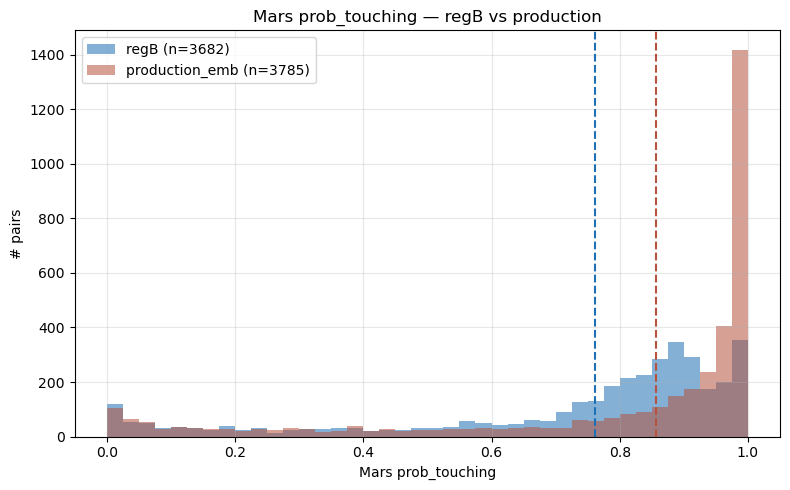

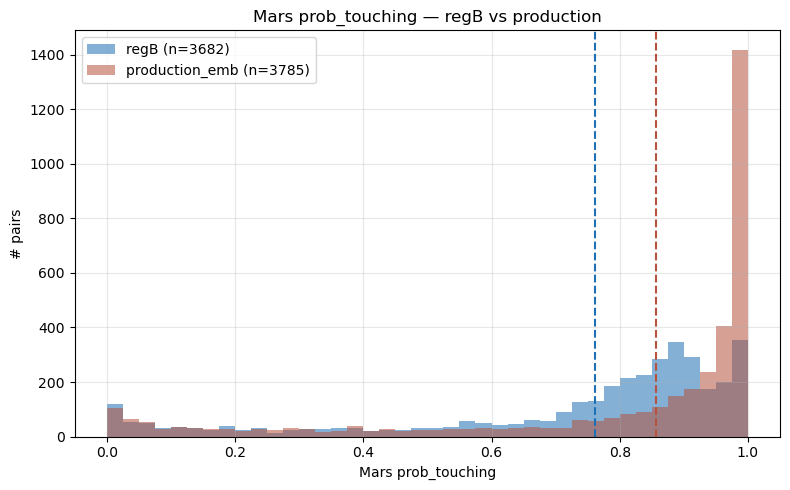

In [4]:
mars = {
    "regB": (PROJECT_ROOT / "data/Mars/model_outputs/mars_combined_regB_predictions.parquet", "prob_touching"),
    "production_emb": (PROJECT_ROOT / "data/Mars/model_outputs/mars_combined_model_predictions.parquet", "prob_touching_emb"),
}
fig, ax = plt.subplots(figsize=(8, 5))
bins = np.linspace(0, 1, 41)
for name, (path, col) in mars.items():
    if not path.exists() or name not in results:
        continue
    probs = pd.read_parquet(path)[col]
    ax.hist(probs, bins=bins, alpha=0.55, color=results[name]["color"], label=f"{name} (n={len(probs)})")
    ax.axvline(results[name]["thr"], color=results[name]["color"], ls="--", lw=1.5)
    print(f"{name:15s} median={probs.median():.3f}  frac>=0.5={ (probs>=0.5).mean():.1%}  frac>=0.9={(probs>=0.9).mean():.1%}")
ax.set_xlabel("Mars prob_touching"); ax.set_ylabel("# pairs")
ax.set_title("Mars prob_touching — regB vs production"); ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout()
fig

---
Full run (writes the PNG diagnostics to `data/results/`):

```bash
python scripts/diagnostics/diag_regB_threshold.py
```